# Decision 3 — Capital Adequacy under Vendor Uncertainty

**Mechanism.** Physical flood damage raises borrower PD and LGD. Under the Basel III IRB framework, higher PD and LGD feed directly into the Vasicek capital charge formula, inflating risk-weighted assets (RWA). Because the bank's equity capital is fixed in the short run, rising RWA compresses the CET1 ratio. Vendor disagreement on damage ratios therefore propagates into a distribution of CET1 outcomes — some above the regulatory minimum, some below. This creates a binary cliff: a small change in which vendor the bank consults can flip the assessment from adequately capitalised to in breach.

**Framing.** The analysis uses a **shock scenario**: the 1-in-200yr flood is treated as certain (p = 1). This isolates the vendor disagreement effect without probability dilution.

**Transmission.** Reduced-form linear model: PD(d) = PD₀ × (1 + α × d); LGD(d) = min(LGD₀ + λ × d, 1). Stressed PD and LGD feed into the Basel III IRB Vasicek formula to produce per-loan capital charges K and stressed RWA.

**Capital.** CET1_stressed = Capital₀ / RWA_stressed. Capital₀ is fixed; RWA inflates as PD/LGD increase. The bank is calibrated at CET1 = 5.5% (a stressed bank with a thin buffer above the 4.5% minimum), so that realistic flood damage ratios are sufficient to trigger a breach for a meaningful fraction of vendor draws.


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm as _norm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE, RED, GREY, AMBER = '#4878CF', '#E84D0E', '#888888', '#F0A500'

In [25]:
# =============================================================================
# PARAMETERS -- edit this cell to explore how results change
# =============================================================================

# --- Seeds (match Decision 1 for portfolio consistency) ---
PORTFOLIO_SEED = 42
VENDOR_SEED    = 1       # single-vendor display cells
N_DRAWS        = 2000    # vendor uncertainty simulation

# --- Probability framing ---
# 'shock'         : flood treated as certain (p_flood = 1.0); recommended for D3.
# 'unconditional' : probability-weighted by 200yr RP (p_flood = 1/200).
FRAMING        = 'shock'
P_FLOOD_ANNUAL = 1 / 200

# --- Reduced-form transmission parameters (linear model) ---
# ALPHA=4: PD doubles at d=0.25, triples at d=0.50. Calibrated so that the
# damage ratios observed in CFRF data produce CET1 outcomes that straddle
# the regulatory minimum across the vendor population.
ALPHA  = 4.0    # PD sensitivity:  PD(d) = PD_0 * (1 + alpha * d)
LAMBDA = 0.30   # LGD sensitivity: LGD(d) = min(LGD_0 + lambda * d, 1.0)

# --- Portfolio parameters (SME/corporate CRE book) ---
# Higher PD_0 and LGD_0 than Decision 1 — reflects a corporate/CRE loan book
# where flood risk is more material and baseline credit quality is lower.
EAD_LOW,   EAD_HIGH   = 0.5,    5.0    # GBPm, Uniform
PD0_MU,    PD0_SIGMA  = -4.0,   1.0    # LogNormal; median ~1.8%, range 0.3-10%
LGD0_LOW,  LGD0_HIGH  = 0.25,   0.45   # Uniform; higher than D1 (less collateral protection)
MAT_LOW,   MAT_HIGH   = 3,      15     # years, Uniform int

# --- Capital parameters ---
# Stressed bank calibration: CET1 just above regulatory minimum.
# Buffer = 5.5% - 4.5% = 100 bps. Realistic for a bank under PRA supervisory pressure.
# RWA is derived from the IRB Vasicek formula (not a fixed density), so
# stressed PD/LGD directly inflates RWA and compresses the CET1 ratio.
CET1_THRESHOLD = 0.045   # Basel III regulatory minimum CET1
CET1_START     = 0.055   # bank's starting CET1 (thin buffer, stressed bank)

# --- Pairwise vendor comparison ---
VENDOR_A = 1
VENDOR_B = 2

# --- Data ---
DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'


In [26]:
# =============================================================================
# DATA, PORTFOLIO, AND CAPITAL CALIBRATION
# Run this cell after editing parameters above.
# =============================================================================

# ── Load CFRF/GARP flood data ─────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n = len(df)

# Triangular distribution parameters (mode from mean constraint: c = 3μ − min − max)
tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

def triangular_sample(rng, a, b, c):
    """Draw one sample per property from Triangular(a, c, b) via inverse CDF."""
    u     = rng.uniform(size=len(a))
    span  = np.where(b > a, b - a, 1.0)
    fc    = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u,       0) * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u,   0) * span * np.maximum(b - c, 0))
    x     = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)

# ── Sample one vendor draw ────────────────────────────────────────────────────
vendor_rng = np.random.default_rng(VENDOR_SEED)
d_vendor   = triangular_sample(vendor_rng, tri_a, tri_b, tri_c)

# ── Loan portfolio ────────────────────────────────────────────────────────────
port_rng = np.random.default_rng(PORTFOLIO_SEED)
ead  = port_rng.uniform(EAD_LOW, EAD_HIGH, size=n)
pd0  = np.clip(
    stats.lognorm.rvs(s=PD0_SIGMA, scale=np.exp(PD0_MU), size=n,
                      random_state=int(port_rng.integers(2**31))),
    1e-4, 0.9999
)
lgd0 = port_rng.uniform(LGD0_LOW, LGD0_HIGH, size=n)
mat  = port_rng.integers(MAT_LOW, MAT_HIGH + 1, size=n).astype(float)
el0  = ead * pd0 * lgd0   # baseline expected loss per loan

# ── Basel III IRB Vasicek capital charge ─────────────────────────────────────
# K(PD, LGD, M) = IRB capital charge per unit of EAD.
# RWA = 12.5 × K × EAD.  CET1_stressed = Capital_0 / RWA_stressed.
def vasicek_K(pd_arr, lgd_arr, m_arr):
    """Vectorised Basel III IRB Vasicek capital charge."""
    pd_c = np.clip(pd_arr, 0.0003, 0.9999)
    f    = (1.0 - np.exp(-50.0 * pd_c)) / (1.0 - np.exp(-50.0))
    R    = 0.12 * f + 0.24 * (1.0 - f)          # asset correlation
    b    = (0.11852 - 0.05478 * np.log(pd_c)) ** 2
    ma   = (1.0 + (m_arr - 2.5) * b) / (1.0 - 1.5 * b)   # maturity adjustment
    K    = (lgd_arr * _norm.cdf(_norm.ppf(pd_c) / np.sqrt(1.0 - R)
                                + np.sqrt(R / (1.0 - R)) * _norm.ppf(0.999))
            - lgd_arr * pd_c) * ma
    return np.maximum(K, 0.0)

# ── Baseline RWA and capital ──────────────────────────────────────────────────
k0_loans  = vasicek_K(pd0, lgd0, mat)
rwa_0_loans = 12.5 * k0_loans * ead
RWA_0     = rwa_0_loans.sum()
Capital_0 = CET1_START * RWA_0
EL_0      = el0.sum()

# Breach occurs when RWA_stressed > Capital_0 / CET1_THRESHOLD
max_rwa_before_breach = Capital_0 / CET1_THRESHOLD   # = (CET1_START/CET1_THRESHOLD) * RWA_0
buffer_bps = (CET1_START - CET1_THRESHOLD) * 1e4

# ── Sort index (shared by figure cells) ──────────────────────────────────────
idx   = np.argsort(df['mean_dr'].values)
x_pos = np.arange(n)

print('=== Capital calibration (IRB Vasicek) ===')
print(f'  Total EAD:              GBP{ead.sum():.2f}m')
print(f'  Baseline RWA (IRB):     GBP{RWA_0:.2f}m  ({RWA_0/ead.sum()*100:.0f}% of EAD)')
print(f'  Capital_0:              GBP{Capital_0:.3f}m')
print(f'  Baseline CET1:          {CET1_START*100:.1f}%')
print(f'  CET1 threshold:         {CET1_THRESHOLD*100:.1f}%')
print(f'  Buffer above threshold: {buffer_bps:.0f} bps')
print(f'  Max RWA before breach:  GBP{max_rwa_before_breach:.2f}m  ({max_rwa_before_breach/RWA_0:.3f}x baseline)')
print(f'  Median baseline PD:     {np.median(pd0)*100:.2f}%')
print(f'  Median baseline LGD:    {np.median(lgd0)*100:.1f}%')
print(f'  Baseline EL:            GBP{EL_0:.4f}m')


=== Capital calibration ===
  Total EAD:              GBP269.02m
  RWA density:            100% of EAD
  Baseline RWA:           GBP269.02m
  Capital_0  (CET1 × RWA): GBP32.283m
  Baseline CET1:          12.0%
  CET1 threshold:         4.5%
  Buffer above threshold: 750 bps
  Max shock loss before breach: GBP20.177m
  Baseline EL:            GBP0.4751m  (2.4% of buffer)


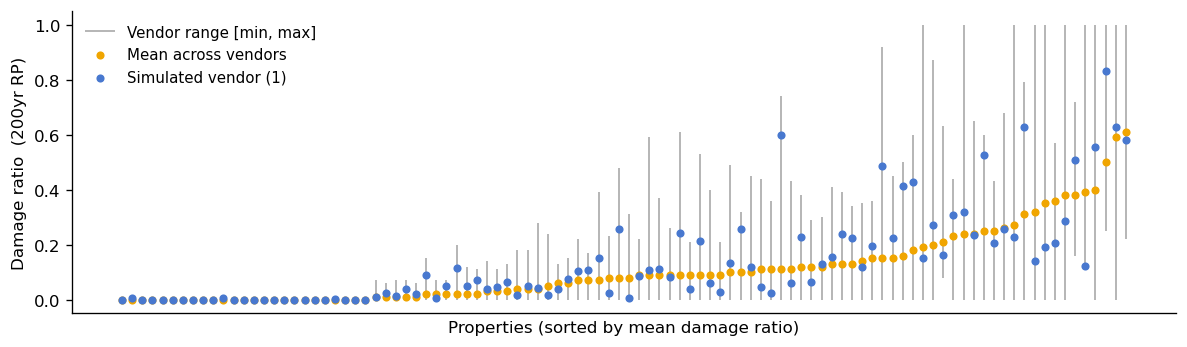

In [27]:
# Standard opening figure: vendor damage ratio spread per property (as in D1)
mean_d   = df['mean_dr'].values[idx]
min_d    = tri_a[idx]
max_d    = tri_b[idx]
vendor_d = d_vendor[idx]

fig, ax = plt.subplots(figsize=(10, 3))
ax.vlines(x_pos, min_d, max_d, color=GREY, linewidth=1.2, alpha=0.6,
          label='Vendor range [min, max]')
ax.scatter(x_pos, mean_d,   color=AMBER, s=15, zorder=3, label='Mean across vendors')
ax.scatter(x_pos, vendor_d, color=BLUE,  s=15, zorder=3, label=f'Simulated vendor ({VENDOR_SEED})')
ax.set_xlabel('Properties (sorted by mean damage ratio)')
ax.set_ylabel('Damage ratio  (200yr RP)')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

In [28]:
# =============================================================================
# SINGLE-VENDOR TRANSMISSION  (uses VENDOR_SEED from parameters)
# =============================================================================
framing_label = ('Shock (flood certain, p=1)' if FRAMING == 'shock'
                 else f'Unconditional (p={P_FLOOD_ANNUAL:.4f})')

d_eff  = d_vendor * (P_FLOOD_ANNUAL if FRAMING == 'unconditional' else 1.0)
pd_v   = np.clip(pd0 * (1.0 + ALPHA * d_eff), 0, 0.9999)
lgd_v  = np.minimum(lgd0 + LAMBDA * d_eff, 1.0)
el_v   = ead * pd_v * lgd_v     # per-loan expected loss (used for Fig 1)

# ── IRB Vasicek: stressed RWA and CET1 ratio ─────────────────────────────────
k_v        = vasicek_K(pd_v, lgd_v, mat)
rwa_v_loans = 12.5 * k_v * ead
RWA_v      = rwa_v_loans.sum()
rwa_ratio_v = RWA_v / RWA_0
CET1_v     = Capital_0 / RWA_v
breach_v   = CET1_v < CET1_THRESHOLD
Loss_v     = el_v.sum() - EL_0   # EL increment — for display only

print(f'Framing: {framing_label}  |  Vendor seed: {VENDOR_SEED}')
print(f'  Baseline RWA:           GBP{RWA_0:.3f}m')
print(f'  Stressed RWA (IRB):     GBP{RWA_v:.3f}m  ({rwa_ratio_v:.4f}x baseline)')
print(f'  CET1 ratio:             {CET1_v*100:.3f}%  (start: {CET1_START*100:.1f}%,  threshold: {CET1_THRESHOLD*100:.1f}%)')
print(f'  Breach:                 {"YES" if breach_v else "no"}  |  '
      f'Buffer: {(CET1_v - CET1_THRESHOLD)*1e4:.0f} bps')
print(f'  EL increment (display): GBP{Loss_v:.4f}m')


Framing: Shock (flood certain, p=1)  |  Vendor seed: 1
  Baseline EL:             GBP0.4751m
  Stressed EL:             GBP0.7845m
  Shock loss (unexpected): GBP0.3093m  (charged against capital)
  Capital after shock:     GBP31.9735m
  CET1 ratio:              11.885%  (start: 12.0%,  threshold: 4.5%)
  Breach:                  no  |  Buffer: 739 bps


**Figure 1 — Damage ratio vs. loan-level expected loss (single vendor).** Each point is one loan; x-axis is the vendor's damage ratio for that property and y-axis is the resulting stressed EL in GBP thousands. Loans coloured red have a stressed EL above their baseline; blue loans are unchanged (zero or negligible damage). The panel communicates which part of the portfolio drives the capital depletion and whether high-loss loans cluster at high-damage properties.

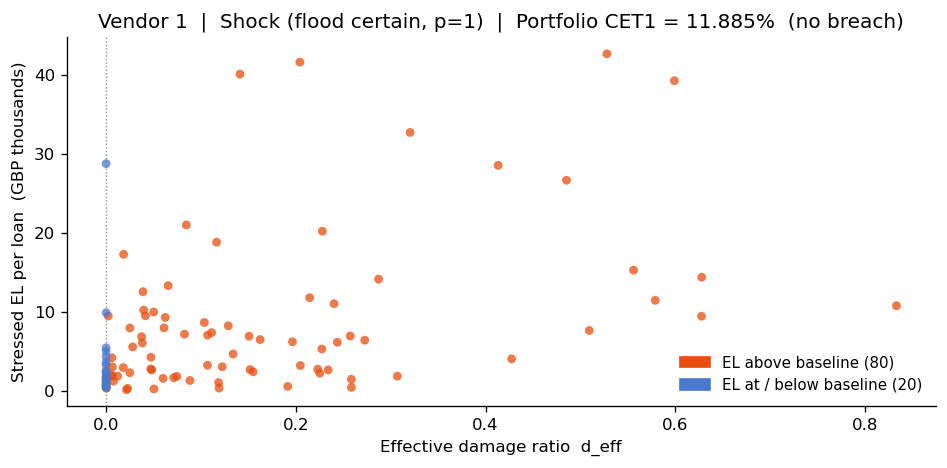

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
colours_1 = np.where(el_v > el0, RED, BLUE)
ax.scatter(d_eff, el_v * 1e3, c=colours_1, s=28, alpha=0.75, edgecolors='none', zorder=3)
ax.axvline(0, color=GREY, lw=0.8, ls=':')
ax.set_xlabel('Effective damage ratio  d_eff')
ax.set_ylabel('Stressed EL per loan  (GBP thousands)')
ax.set_title(
    f'Vendor {VENDOR_SEED}  |  {framing_label}  |  '
    f'Portfolio CET1 = {CET1_v*100:.3f}%  '
    f'({"BREACH" if breach_v else "no breach"})'
)
ax.legend(handles=[
    mpatches.Patch(color=RED,  label=f'EL above baseline ({(el_v > el0).sum()})'),
    mpatches.Patch(color=BLUE, label=f'EL at / below baseline ({(el_v <= el0).sum()})'),
], frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

In [30]:
# =============================================================================
# VENDOR UNCERTAINTY SIMULATION  (N_DRAWS draws from triangular distributions)
# =============================================================================
_rng_n = np.random.default_rng(0)

# Vectorised triangular draws: shape (N_DRAWS, n)
u_mat  = _rng_n.uniform(size=(N_DRAWS, n))
span   = np.where(tri_b > tri_a, tri_b - tri_a, 1.0)
fc     = np.where(tri_b > tri_a, (tri_c - tri_a) / span, 0.0)
_left  = tri_a + np.sqrt(np.maximum(u_mat,       0) * span * np.maximum(tri_c - tri_a, 0))
_right = tri_b - np.sqrt(np.maximum(1.0 - u_mat, 0) * span * np.maximum(tri_b - tri_c, 0))
d_mat  = np.where(u_mat <= fc, _left, _right)
d_mat  = np.where(tri_b > tri_a, np.clip(d_mat, 0, 1), tri_a)

# Apply probability framing
d_eff_mat = d_mat * (P_FLOOD_ANNUAL if FRAMING == 'unconditional' else 1.0)

# Transmission: (N_DRAWS, n)
pd_mat  = np.clip(pd0[None, :] * (1.0 + ALPHA * d_eff_mat), 1e-4, 0.9999)
lgd_mat = np.minimum(lgd0[None, :] + LAMBDA * d_eff_mat, 1.0)

# ── IRB Vasicek: stressed RWA per draw ───────────────────────────────────────
# Broadcast mat across draws: shape (N_DRAWS, n)
mat_mat        = np.broadcast_to(mat[None, :], pd_mat.shape)
k_mat          = vasicek_K(pd_mat, lgd_mat, mat_mat)
rwa_loans_mat  = 12.5 * k_mat * ead[None, :]
rwa_stressed_draws = rwa_loans_mat.sum(axis=1)   # (N_DRAWS,)
rwa_ratio_draws    = rwa_stressed_draws / RWA_0

# CET1 ratio per draw: Capital fixed, RWA inflates
cet1_draws   = Capital_0 / rwa_stressed_draws
breach_draws = cet1_draws < CET1_THRESHOLD

# EL draws — kept for display in Figure 1 scatter
el_mat     = ead[None, :] * pd_mat * lgd_mat
loss_draws = el_mat.sum(axis=1) - EL_0

p_breach = breach_draws.mean()
print(f'N_DRAWS = {N_DRAWS}  |  {framing_label}')
print(f'  Breach probability:        {p_breach:.2%}')
print(f'  CET1 mean:                 {cet1_draws.mean()*100:.3f}%')
print(f'  CET1 std:                  {cet1_draws.std()*100:.3f}%')
print(f'  CET1 P5:                   {np.percentile(cet1_draws, 5)*100:.3f}%')
print(f'  CET1 P50:                  {np.percentile(cet1_draws, 50)*100:.3f}%')
print(f'  CET1 P95:                  {np.percentile(cet1_draws, 95)*100:.3f}%')
print(f'  RWA ratio mean:            {rwa_ratio_draws.mean():.4f}x')
print(f'  RWA ratio std:             {rwa_ratio_draws.std():.4f}x')
print(f'  RWA ratio range:           [{rwa_ratio_draws.min():.4f}, {rwa_ratio_draws.max():.4f}]x')


N_DRAWS = 100  |  Shock (flood certain, p=1)
  Breach probability:        0.00%
  CET1 mean:                 11.893%
  CET1 std:                  0.015%
  CET1 P5:                   11.865%
  CET1 P50:                  11.894%
  CET1 P95:                  11.916%
  Shock loss mean:           GBP0.2891m
  Shock loss P95:            GBP0.3626m


**Figure 2 — CET1 ratio distribution across vendor draws.** Each draw represents a bank using a different commercial vendor's flood damage estimates for the same portfolio. The histogram shows how widely the estimated CET1 ratio varies across the vendor population. The dashed red line marks the regulatory minimum; bars left of this line represent vendors whose damage estimates would — if taken at face value — indicate a capital breach.

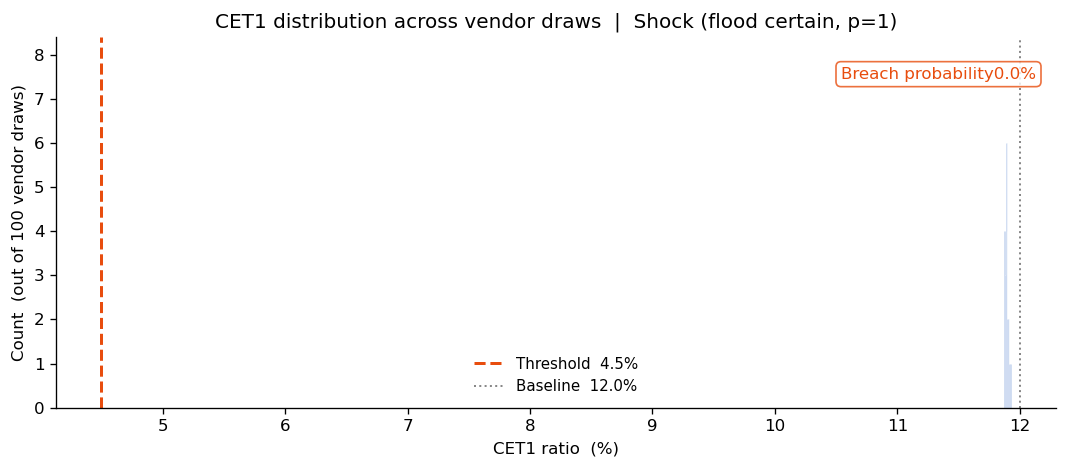

In [31]:
fig, ax = plt.subplots(figsize=(9, 4))
bins_c = np.linspace(cet1_draws.min() * 100, cet1_draws.max() * 100, 60)
bar_colours_c = [RED if c < CET1_THRESHOLD else BLUE
                 for c in (0.5 * (bins_c[:-1] + bins_c[1:]) / 100)]
counts_c, _, patches_c = ax.hist(cet1_draws * 100, bins=bins_c,
                                  edgecolor='white', linewidth=0.3)
for patch, col in zip(patches_c, bar_colours_c):
    patch.set_facecolor(col)
    patch.set_alpha(0.8)
ax.axvline(CET1_THRESHOLD * 100, color=RED,  lw=1.8, ls='--',
           label=f'Threshold  {CET1_THRESHOLD*100:.1f}%')
ax.axvline(CET1_START * 100,     color=GREY, lw=1.2, ls=':',
           label=f'Baseline  {CET1_START*100:.1f}%')
ax.text(0.98, 0.92, f'Breach probability{p_breach:.1%}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color=RED,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=RED, alpha=0.8))
ax.set_xlabel('CET1 ratio  (%)')
ax.set_ylabel(f'Count  (out of {N_DRAWS} vendor draws)')
ax.set_title(f'CET1 distribution across vendor draws  |  {framing_label}')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Figure 3 — Stressed RWA ratio vs. CET1 (scatter).** Each point is one vendor draw. The x-axis is the ratio of stressed to baseline RWA: values above 1.0 mean the vendor's damage estimates increase the IRB capital charge. The y-axis is the resulting CET1 ratio. The vertical dashed line marks the maximum RWA inflation compatible with remaining above the regulatory minimum; draws to the right of this line represent breaches.


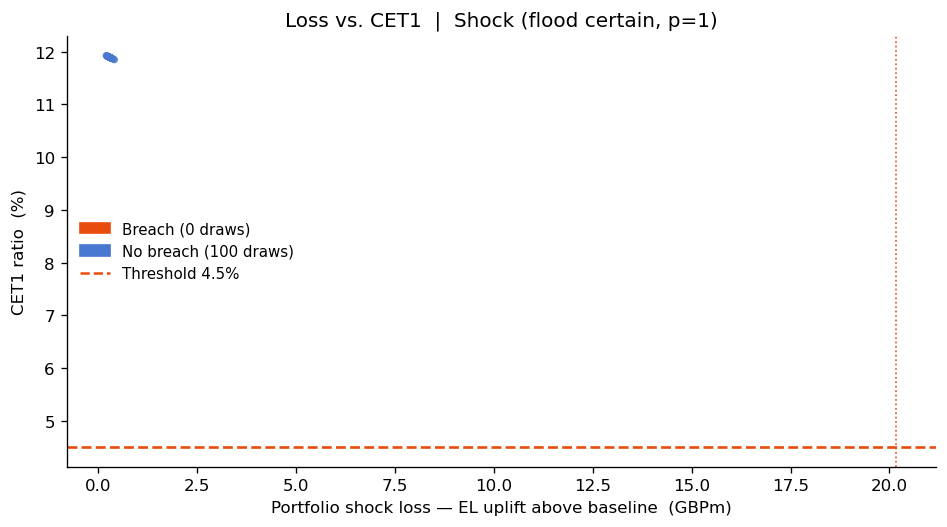

In [32]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colours_3 = np.where(breach_draws, RED, BLUE)
ax.scatter(rwa_ratio_draws, cet1_draws * 100, c=colours_3, s=18, alpha=0.55,
           edgecolors='none', zorder=3)
ax.axhline(CET1_THRESHOLD * 100, color=RED, lw=1.6, ls='--',
           label=f'Threshold  {CET1_THRESHOLD*100:.1f}%')
ax.axvline(max_rwa_before_breach / RWA_0, color=RED, lw=1.0, ls=':',
           label=f'Max RWA ratio before breach  ({max_rwa_before_breach/RWA_0:.3f}x)')
ax.set_xlabel('Stressed RWA / Baseline RWA')
ax.set_ylabel('CET1 ratio  (%)')
ax.set_title(f'RWA inflation vs. CET1  |  {framing_label}')
ax.legend(handles=[
    mpatches.Patch(color=RED,  label=f'Breach ({breach_draws.sum()} draws)'),
    mpatches.Patch(color=BLUE, label=f'No breach ({(~breach_draws).sum()} draws)'),
    plt.Line2D([0],[0], color=RED, ls='--', label=f'Threshold {CET1_THRESHOLD*100:.1f}%'),
], frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


**Figure 4 — Capital cliff proximity.** The x-axis shows each vendor draw's CET1 buffer above (positive) or below (negative) the regulatory minimum. The shaded red region to the left of zero represents capital breaches. The distribution of buffers communicates not just whether a breach occurs but how *close* the bank is to the cliff across the vendor population — a wide spread near zero indicates high sensitivity to vendor model choice.

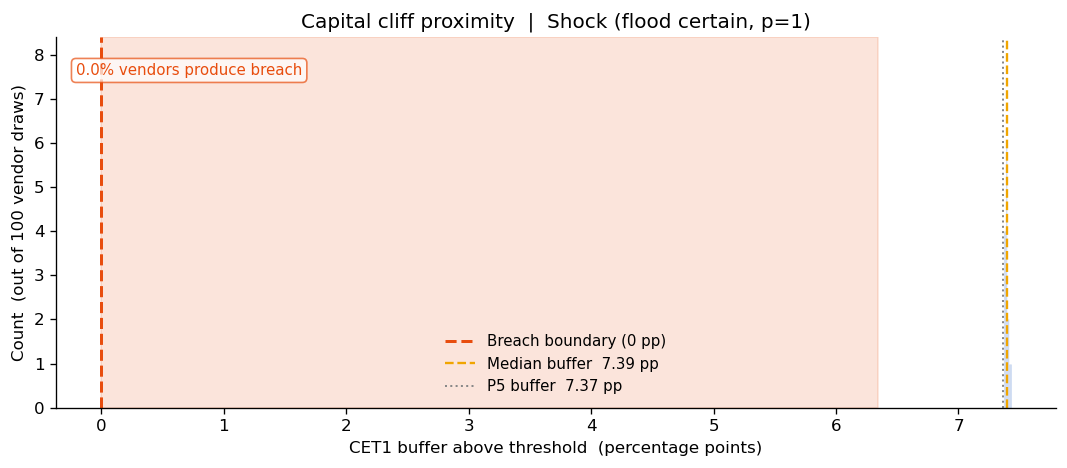

In [33]:
buffer_draws = (cet1_draws - CET1_THRESHOLD) * 100   # percentage points
median_buf = np.median(buffer_draws)
p5_buf     = np.percentile(buffer_draws, 5)

fig, ax = plt.subplots(figsize=(9, 4))
bins_b = np.linspace(buffer_draws.min(), buffer_draws.max(), 60)
ax.hist(buffer_draws, bins=bins_b, color=BLUE, alpha=0.75, edgecolor='white', linewidth=0.3)
# Shade breach region
xlim = ax.get_xlim()
ax.axvspan(buffer_draws.min() - 1, 0, alpha=0.15, color=RED, zorder=0)
ax.axvline(0,          color=RED,  lw=1.8, ls='--', label='Breach boundary (0 pp)')
ax.axvline(median_buf, color=AMBER, lw=1.4, ls='--', label=f'Median buffer  {median_buf:.2f} pp')
ax.axvline(p5_buf,     color=GREY,  lw=1.2, ls=':',  label=f'P5 buffer  {p5_buf:.2f} pp')
ax.set_xlabel('CET1 buffer above threshold  (percentage points)')
ax.set_ylabel(f'Count  (out of {N_DRAWS} vendor draws)')
ax.set_title(f'Capital cliff proximity  |  {framing_label}')
ax.legend(frameon=False, fontsize=9)
ax.text(0.02, 0.93, f'{p_breach:.1%} vendors produce breach',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=9, color=RED,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=RED, alpha=0.7))
plt.tight_layout()
plt.show()

**Figure 5 — Vendor A vs. Vendor B: loan-level loss comparison.** The left panel shows per-loan stressed EL for two specific vendors (sorted by absolute disagreement), highlighting which loans drive the difference. The right panel translates these losses to CET1 ratios and annotates whether each vendor triggers a breach, making the stake of vendor choice concrete.

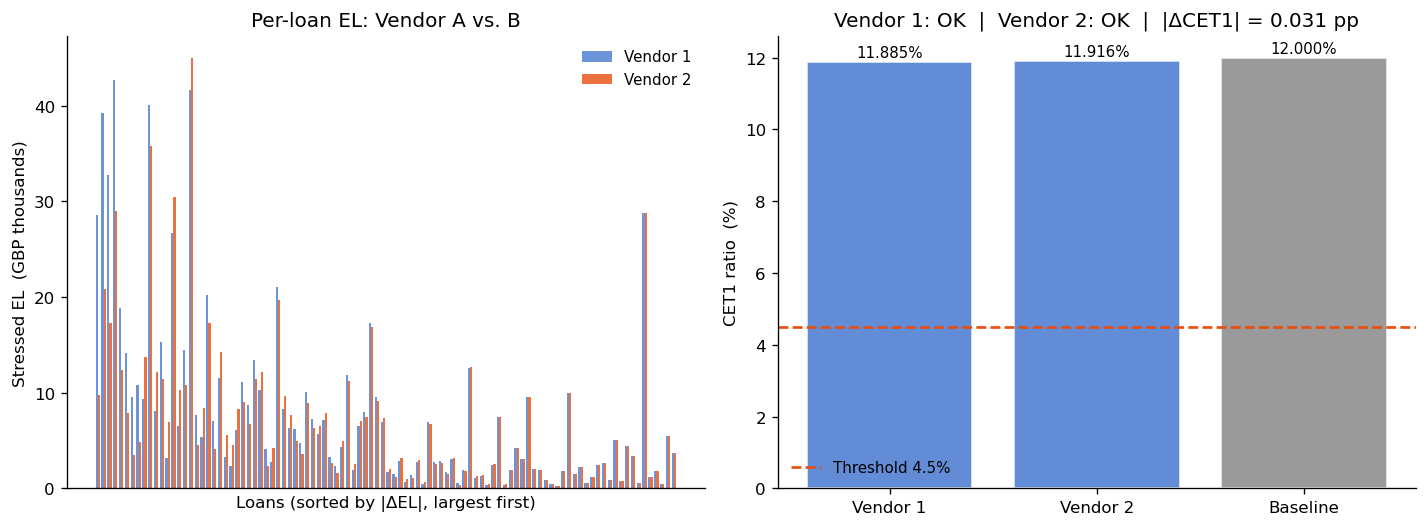

In [34]:
# Vendor A and B draws
d_A = triangular_sample(np.random.default_rng(VENDOR_A), tri_a, tri_b, tri_c)
d_B = triangular_sample(np.random.default_rng(VENDOR_B), tri_a, tri_b, tri_c)

def _transmit_single(d_raw):
    d_e    = d_raw * (P_FLOOD_ANNUAL if FRAMING == 'unconditional' else 1.0)
    pd_v   = np.clip(pd0 * (1.0 + ALPHA * d_e), 1e-4, 0.9999)
    lgd_v  = np.minimum(lgd0 + LAMBDA * d_e, 1.0)
    el     = ead * pd_v * lgd_v
    # IRB Vasicek RWA
    k_v    = vasicek_K(pd_v, lgd_v, mat)
    rwa_v  = (12.5 * k_v * ead).sum()
    cet1   = Capital_0 / rwa_v
    loss   = el.sum() - EL_0   # EL increment, for display
    return el, loss, cet1, rwa_v

el_A, Loss_A, CET1_A, RWA_A = _transmit_single(d_A)
el_B, Loss_B, CET1_B, RWA_B = _transmit_single(d_B)
breach_A = CET1_A < CET1_THRESHOLD
breach_B = CET1_B < CET1_THRESHOLD

# Sort loans by absolute disagreement in EL
order_ab = np.argsort(np.abs(el_A - el_B))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: per-loan EL comparison ─────────────────────────────────────────────
ax = axes[0]
x_ab = np.arange(n)
w = 0.38
ax.bar(x_ab - w/2, el_A[order_ab] * 1e3, width=w, color=BLUE, alpha=0.8,
       label=f'Vendor {VENDOR_A}')
ax.bar(x_ab + w/2, el_B[order_ab] * 1e3, width=w, color=RED,  alpha=0.8,
       label=f'Vendor {VENDOR_B}')
ax.set_xlabel('Loans (sorted by |ΔEL|, largest first)')
ax.set_ylabel('Stressed EL  (GBP thousands)')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9)
ax.set_title('Per-loan EL: Vendor A vs. B')

# ── Right: CET1 ratio comparison ─────────────────────────────────────────────
ax = axes[1]
bar_data   = [CET1_A * 100, CET1_B * 100, CET1_START * 100]
bar_labels = [f'Vendor {VENDOR_A}', f'Vendor {VENDOR_B}', 'Baseline']
bar_cols   = [RED if breach_A else BLUE, RED if breach_B else BLUE, GREY]
bars = ax.bar(bar_labels, bar_data, color=bar_cols, alpha=0.85, edgecolor='white')
ax.axhline(CET1_THRESHOLD * 100, color=RED, lw=1.6, ls='--',
           label=f'Threshold {CET1_THRESHOLD*100:.1f}%')
for bar, val in zip(bars, bar_data):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('CET1 ratio  (%)')
ax.set_title(
    f'Vendor {VENDOR_A}: {"BREACH" if breach_A else "OK"}  |  '
    f'Vendor {VENDOR_B}: {"BREACH" if breach_B else "OK"}  |  '
    f'|ΔCET1| = {abs(CET1_A - CET1_B)*100:.3f} pp'
)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


**Figure 6 — RWA ratio and CET1 across sorted vendor draws.** Vendor draws are sorted by stressed RWA (x-axis). The left y-axis shows the ratio of stressed to baseline RWA; the right y-axis shows the implied CET1 ratio. The light red shaded region marks draws where CET1 falls below the regulatory minimum. This makes visible both the fraction of vendor draws that trigger a breach and the range of RWA inflation the bank faces depending on which vendor it consults.


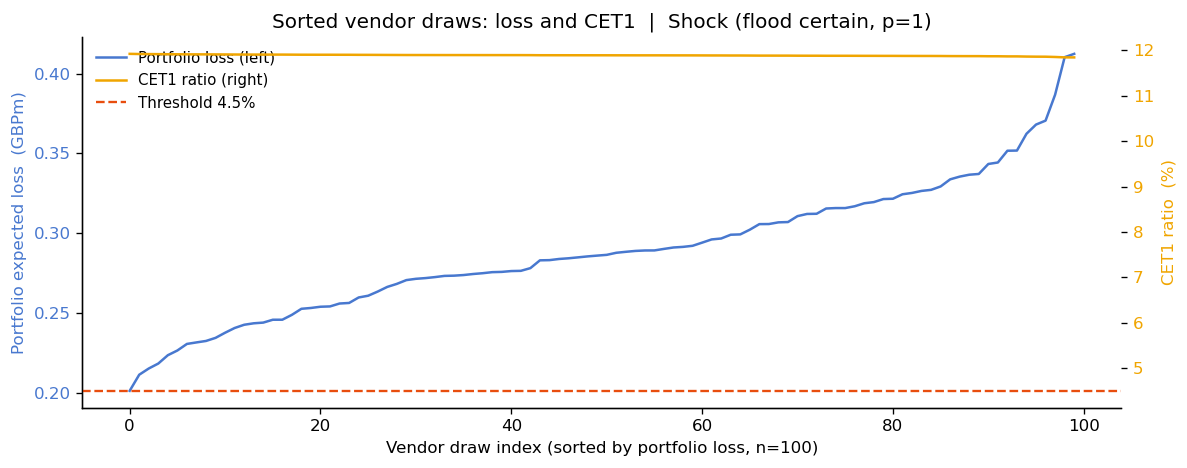

In [35]:
order_rwa  = np.argsort(rwa_ratio_draws)
rwa_sorted  = rwa_ratio_draws[order_rwa]
cet1_sorted = cet1_draws[order_rwa]
x_draws = np.arange(N_DRAWS)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

# Shade breach region
breach_indices = np.where(cet1_sorted < CET1_THRESHOLD)[0]
if len(breach_indices) > 0:
    ax1.axvspan(breach_indices[0], N_DRAWS - 1, alpha=0.12, color=RED, zorder=0,
                label=f'Breach zone ({len(breach_indices)} draws)')

ax1.plot(x_draws, rwa_sorted, color=BLUE, lw=1.5, label='Stressed RWA / Baseline RWA (left)')
ax1.axhline(max_rwa_before_breach / RWA_0, color=RED, lw=1.0, ls=':',
            label=f'Max RWA ratio before breach ({max_rwa_before_breach/RWA_0:.3f}x)')
ax2.plot(x_draws, cet1_sorted * 100, color=AMBER, lw=1.5, label='CET1 ratio (right)')
ax2.axhline(CET1_THRESHOLD * 100, color=RED, lw=1.4, ls='--',
            label=f'Threshold {CET1_THRESHOLD*100:.1f}%')

ax1.set_xlabel(f'Vendor draw index (sorted by stressed RWA, n={N_DRAWS})')
ax1.set_ylabel('Stressed RWA ratio  (× baseline)', color=BLUE)
ax2.set_ylabel('CET1 ratio  (%)', color=AMBER)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax2.tick_params(axis='y', labelcolor=AMBER)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9, loc='upper left')
ax1.set_title(f'Sorted vendor draws: RWA inflation and CET1  |  {framing_label}')
plt.tight_layout()
plt.show()


In [36]:
# =============================================================================
# SUMMARY STATISTICS
# =============================================================================
ead_total = ead.sum()
rwa_density_baseline = RWA_0 / ead_total

# ── Section 1: Capital calibration ───────────────────────────────────────────
calib_stats = {
    'Total EAD (GBPm)':                    round(ead_total, 3),
    'Baseline RWA (GBPm)':                 round(RWA_0, 3),
    'RWA density (% of EAD)':              round(rwa_density_baseline * 100, 1),
    'Capital₀ (GBPm)':                     round(Capital_0, 4),
    'Baseline CET1 (%)':                   round(CET1_START * 100, 2),
    'Buffer above threshold (bps)':        round(buffer_bps, 1),
    'Max RWA inflation before breach (x)': round(max_rwa_before_breach / RWA_0, 4),
    'Baseline EL (GBPm)':                  round(EL_0, 4),
    'Median baseline PD (%)':              round(float(np.median(pd0)) * 100, 3),
    'Median baseline LGD (%)':             round(float(np.median(lgd0)) * 100, 1),
}
df_calib = pd.DataFrame({'Baseline': calib_stats})

# ── Sections 2 & 3: CET1 dispersion + stability (N_DRAWS simulation) ─────────
cet1_pct    = cet1_draws * 100
buffer_draws = (cet1_draws - CET1_THRESHOLD) * 100   # pp above threshold per draw
cond_buffer  = buffer_draws[~breach_draws]
rwa_cv      = rwa_ratio_draws.std() / rwa_ratio_draws.mean()

sim_stats = {
    # CET1 dispersion
    'CET1 mean (%)':                       round(float(np.mean(cet1_pct)), 4),
    'CET1 std (%)':                        round(float(np.std(cet1_pct)), 4),
    'CET1 P5 (%)':                         round(float(np.percentile(cet1_pct,  5)), 4),
    'CET1 P25 (%)':                        round(float(np.percentile(cet1_pct, 25)), 4),
    'CET1 P50 (%)':                        round(float(np.percentile(cet1_pct, 50)), 4),
    'CET1 P75 (%)':                        round(float(np.percentile(cet1_pct, 75)), 4),
    'CET1 P95 (%)':                        round(float(np.percentile(cet1_pct, 95)), 4),
    'CET1 range (P95 − P5, pp)':           round(float(np.percentile(cet1_pct, 95) - np.percentile(cet1_pct, 5)), 4),
    # Capital adequacy stability
    'Breach probability (%)':              round(float(p_breach * 100), 3),
    'Mean CET1 buffer | no breach (pp)':   round(float(cond_buffer.mean()) if len(cond_buffer) > 0 else float('nan'), 4),
    'RWA ratio mean (x baseline)':         round(float(rwa_ratio_draws.mean()), 4),
    'RWA ratio std':                        round(float(rwa_ratio_draws.std()), 4),
    'RWA ratio CV across vendors':         round(float(rwa_cv), 4),
}
df_sim = pd.DataFrame({'N_DRAWS simulation': sim_stats})

# ── Section 4: Pairwise vendor comparison ────────────────────────────────────
if breach_A and breach_B:
    breach_label = 'Both'
elif breach_A:
    breach_label = f'Vendor {VENDOR_A} only'
elif breach_B:
    breach_label = f'Vendor {VENDOR_B} only'
else:
    breach_label = 'Neither'

pair_a = {
    'Stressed RWA (GBPm)':  round(RWA_A, 4),
    'RWA ratio (x baseline)': round(RWA_A / RWA_0, 4),
    'CET1 ratio (%)':        round(CET1_A * 100, 4),
    'Breach':                'YES' if breach_A else 'no',
    '|ΔCET1| (pp)':          round(abs(CET1_A - CET1_B) * 100, 4),
    'Breach outcome':        breach_label,
}
pair_b = {
    'Stressed RWA (GBPm)':  round(RWA_B, 4),
    'RWA ratio (x baseline)': round(RWA_B / RWA_0, 4),
    'CET1 ratio (%)':        round(CET1_B * 100, 4),
    'Breach':                'YES' if breach_B else 'no',
    '|ΔCET1| (pp)':          round(abs(CET1_A - CET1_B) * 100, 4),
    'Breach outcome':        breach_label,
}
df_pair = pd.DataFrame({f'Vendor {VENDOR_A}': pair_a, f'Vendor {VENDOR_B}': pair_b})

display(df_calib)
display(df_sim)
display(df_pair)


Framing: Shock (flood certain, p=1)  |  N_DRAWS = 100  |  ALPHA = 2.0 (linear)  |  LAMBDA = 0.25



,Baseline
Total EAD (GBPm),269
RWA density (% of EAD),100
RWA₀ (GBPm),269
Capital₀ (GBPm),32.28
Baseline CET1 (%),12
Baseline EL (GBPm),0.4751
Buffer above threshold (bps),750


,N_DRAWS simulation
CET1 mean (%),11.89
CET1 std (%),0.0155
CET1 P5 (%),11.87
CET1 P25 (%),11.88
CET1 P50 (%),11.89
CET1 P75 (%),11.9
CET1 P95 (%),11.92
"CET1 range (P95 − P5, pp)",0.0506
Breach probability (%),0
Mean CET1 buffer | no breach (pp),7.393


,Vendor 1,Vendor 2,Diff (B − A)
Portfolio loss (GBPm),0.3093,0.2261,-0.0832
CET1 ratio (%),11.88,11.92,+0.0309
Breach,no,no,
|ΔCET1| (pp),0.0309,0.0309,+0
Breach outcome,Neither,Neither,
